In [60]:
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from imageio import imread
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torchsummary import summary
from torchvision import datasets, transforms

In [61]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [62]:
vggnet = torchvision.models.vgg19(pretrained=True)

for p in vggnet.parameters():
    p.requires_grad = False

# set to evaluation mode
vggnet.eval()

vggnet.to(device);

In [63]:
vggnet # it has 2 blocks: features and classifier. We will use the features block for style transfer.

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [64]:
img4content = imread('D:\Pablo_Data\Documentos\VSCode\deep-learning\DUDL_PythonCode\styletransfer\De_nieuwe_vleugel_van_het_Stedelijk_Museum_Amsterdam.jpg')
img4style   = imread('D:\Pablo_Data\Documentos\VSCode\deep-learning\DUDL_PythonCode\styletransfer\Edvard_Munch,_1893,_The_Scream,_oil,_tempera_and_pastel_on_cardboard,_91_x_73_cm,_National_Gallery_of_Norway.jpg')
img4target = np.random.randint(low=0, high=255, size=img4content.shape).astype(np.uint8)

print(img4content.shape, img4style.shape, img4target.shape)

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Pablo\AppData\Local\Temp\ipykernel_13396\3161761965.py:1: SyntaxWarning: invalid escape sequence '\P'
  img4content = imread('D:\Pablo_Data\Documentos\VSCode\deep-learning\DUDL_PythonCode\styletransfer\De_nieuwe_vleugel_van_het_Stedelijk_Museum_Amsterdam.jpg')
C:\Users\Pablo\AppData\Local\Temp\ipykernel_13396\3161761965.py:2: SyntaxWarning: invalid escape sequence '\P'
  img4style   = imread('D:\Pablo_Data\Documentos\VSCode\deep-learning\DUDL_PythonCode\styletransfer\Edvard_Munch,_1893,_The_Scream,_oil,_tempera_and_pastel_on_cardboard,_91_x_73_cm,_National_Gallery_of_Norway.jpg')
C:\Users\Pablo\AppData\Local\Temp\ipykernel_13396\3161761965.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current beha

(1072, 1920, 3) (4000, 3223, 3) (1072, 1920, 3)


In [65]:
# these images are too large, which will make training take a long time
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(256), # this will keep the aspect ratio and resize the smaller edge to 256, which is what VGG19 expects
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

img4content = transform(img4content).unsqueeze(0).to(device)
img4style = transform(img4style).unsqueeze(0).to(device)
img4target = transform(img4target).unsqueeze(0).to(device)

print(img4content.shape, img4style.shape, img4target.shape)

torch.Size([1, 3, 256, 458]) torch.Size([1, 3, 317, 256]) torch.Size([1, 3, 256, 458])


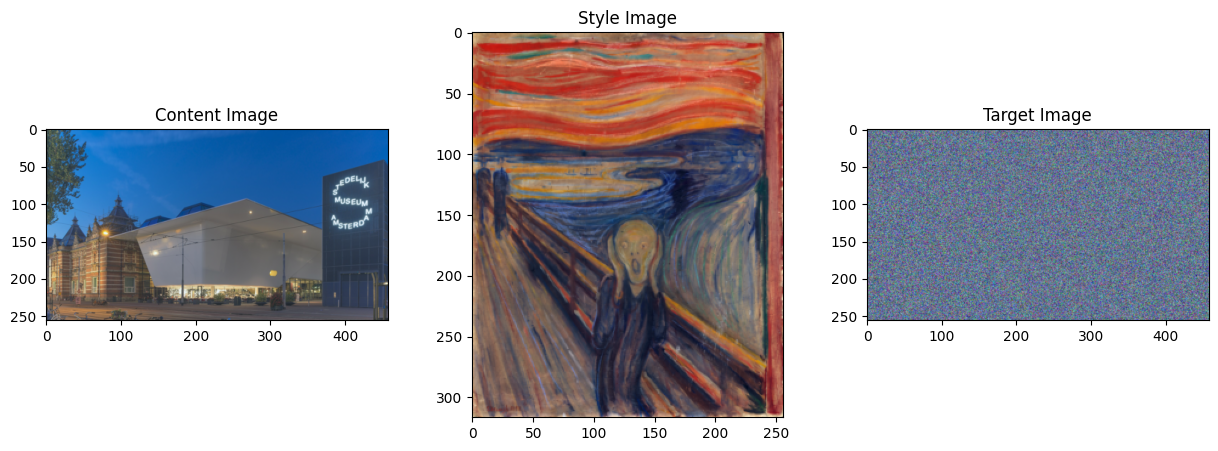

In [66]:
# show the 3 pictures, permutation and normalization are needed to show the images correctly
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
pic_content = img4content.squeeze().cpu().permute(1, 2, 0).numpy()
pic_content = (pic_content - np.min(pic_content)) / (np.max(pic_content) - np.min(pic_content))
axs[0].imshow(pic_content)
axs[0].set_title('Content Image')
pic_style = img4style.squeeze().cpu().permute(1, 2, 0).numpy()
pic_style = (pic_style - np.min(pic_style)) / (np.max(pic_style) - np.min(pic_style))
axs[1].imshow(pic_style)
axs[1].set_title('Style Image')
pic_target = img4target.squeeze().cpu().permute(1, 2, 0).numpy()
pic_target = (pic_target - np.min(pic_target)) / (np.max(pic_target) - np.min(pic_target))
axs[2].imshow(pic_target)
axs[2].set_title('Target Image')
plt.show()

In [67]:
# create a function to extract the features from the VGG19 model
def extract_features(img, model):

    features = {}
    conv_layer_idx = 0
    
    for name, layer in model.features._modules.items():
        # process the image through the layer
        img = layer(img)
        
        # if the layer is a convolutional layer, save the output in the features dictionary
        if isinstance(layer, nn.Conv2d):
            conv_layer_idx += 1
            features[f'conv{conv_layer_idx}'] = img

    return features

# a function that returns the Gram matrix of a given feature map
def gram_matrix(feature_map):
    # reshape the feature map to (C, H*W)
    _, C, H, W = feature_map.size()
    feature_map = feature_map.view(C, H * W)
    
    # compute the Gram matrix
    gram = torch.mm(feature_map, feature_map.t()) / (C * H * W)
    
    return gram

In [68]:
# inspect the output of the function
features_content = extract_features(img4content, vggnet)

# print out some info
for key in features_content.keys():
    print(f'Feature map {key} has shape {features_content[key].shape} and Gram matrix has shape {gram_matrix(features_content[key]).shape}')

Feature map conv1 has shape torch.Size([1, 64, 256, 458]) and Gram matrix has shape torch.Size([64, 64])
Feature map conv2 has shape torch.Size([1, 64, 256, 458]) and Gram matrix has shape torch.Size([64, 64])
Feature map conv3 has shape torch.Size([1, 128, 128, 229]) and Gram matrix has shape torch.Size([128, 128])
Feature map conv4 has shape torch.Size([1, 128, 128, 229]) and Gram matrix has shape torch.Size([128, 128])
Feature map conv5 has shape torch.Size([1, 256, 64, 114]) and Gram matrix has shape torch.Size([256, 256])
Feature map conv6 has shape torch.Size([1, 256, 64, 114]) and Gram matrix has shape torch.Size([256, 256])
Feature map conv7 has shape torch.Size([1, 256, 64, 114]) and Gram matrix has shape torch.Size([256, 256])
Feature map conv8 has shape torch.Size([1, 256, 64, 114]) and Gram matrix has shape torch.Size([256, 256])
Feature map conv9 has shape torch.Size([1, 512, 32, 57]) and Gram matrix has shape torch.Size([512, 512])
Feature map conv10 has shape torch.Size(

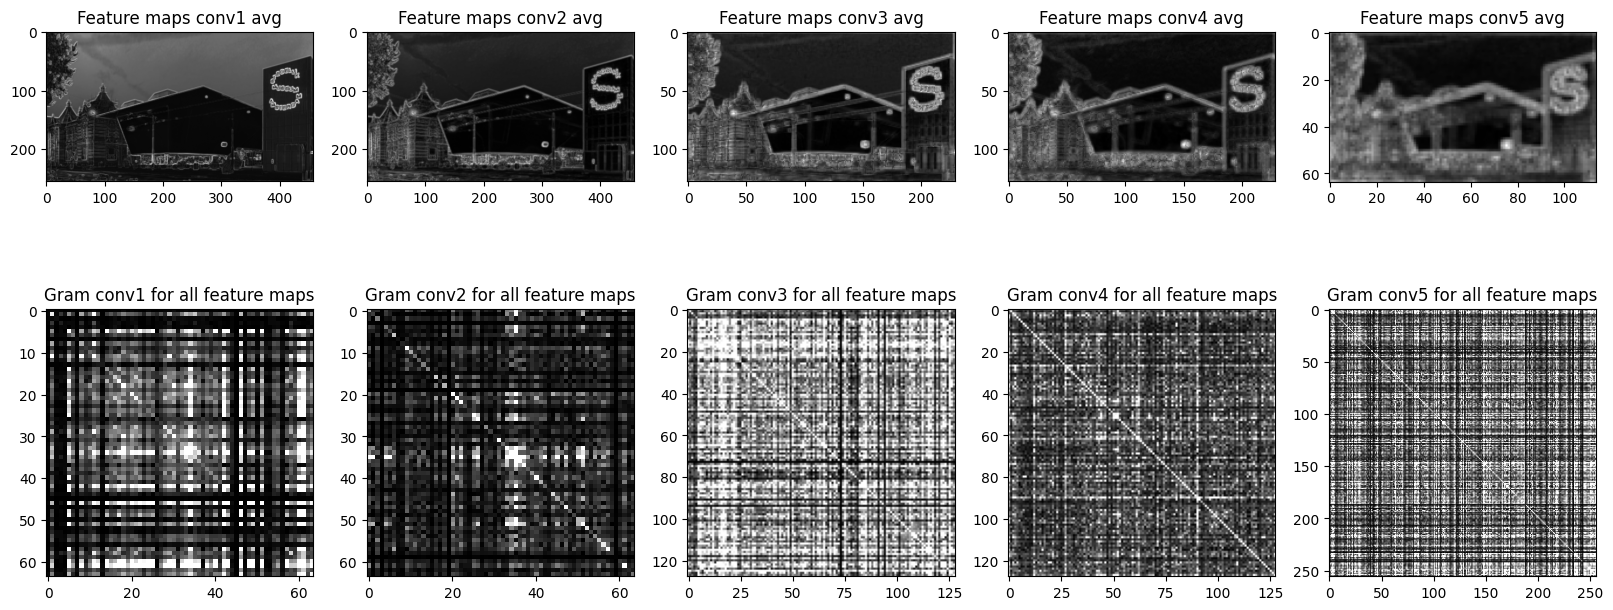

In [69]:
# let's see what the "content" and gram matrix features look like
fig, axs = plt.subplots(2, 5, figsize=(20, 8))

# permutate and normalize the feature maps to show them, select the first 5 feature maps for visualization
for i, key in enumerate(features_content.keys()):
    if i >= 5:
        break
    feature_maps = features_content[key].squeeze().cpu().permute(1, 2, 0).numpy()
    
    # average the feature maps across the channel dimension to get a single 2D feature map
    feature_maps = np.mean(feature_maps, axis=2)
    feature_maps = (feature_maps - np.min(feature_maps)) / (np.max(feature_maps) - np.min(feature_maps))
    axs[0, i].imshow(feature_maps, cmap='gray')
    axs[0, i].set_title(f'Feature maps {key} avg')
    
    gram = gram_matrix(features_content[key]).cpu().numpy()
    gram = (gram - np.min(gram)) / (np.max(gram) - np.min(gram))
    axs[1, i].imshow(gram, cmap='gray', vmax=0.1)
    axs[1, i].set_title(f'Gram {key} for all feature maps')

    # we can see that going through higher layers, the feature maps become more abstract and less similar to the original image, since we are extracting features.
    # the Gram matrix captures the style of the image.

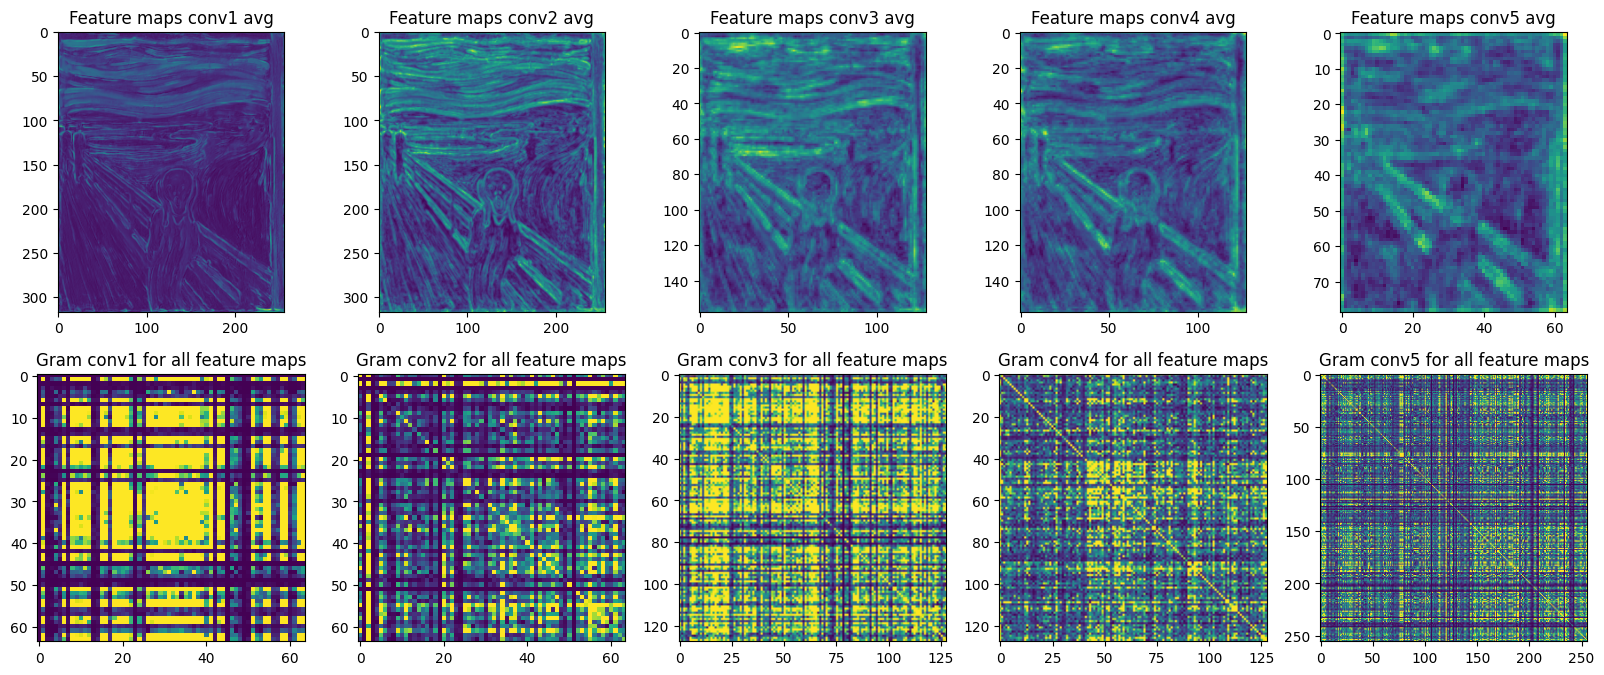

In [70]:
# repeat the same for the style image
features_style = extract_features(img4style, vggnet)

fig, axs = plt.subplots(2, 5, figsize=(20, 8))
# permutate and normalize the feature maps to show them, select the first 5 feature maps for visualization
for i, key in enumerate(features_style.keys()):
    if i >= 5:
        break
    feature_maps = features_style[key].squeeze().cpu().permute(1, 2, 0).numpy()
    
    # average the feature maps across the channel dimension to get a single 2D feature map
    feature_maps = np.mean(feature_maps, axis=2)
    feature_maps = (feature_maps - np.min(feature_maps)) / (np.max(feature_maps) - np.min(feature_maps))
    axs[0, i].imshow(feature_maps)
    axs[0, i].set_title(f'Feature maps {key} avg')
    
    gram = gram_matrix(features_style[key]).cpu().numpy()
    gram = (gram - np.min(gram)) / (np.max(gram) - np.min(gram))
    axs[1, i].imshow(gram, vmax=0.1)
    axs[1, i].set_title(f'Gram {key} for all feature maps')

# Gram matrices capture the style of the image, so we can see that the Gram matrices of the style image are different from those of the content image.

In [71]:
# which layers to use: these selection are metaparameters that we can tune or play with.

# we will use the first and fourth convolutional layers for content loss (or content transfer), since they capture different levels of abstraction in the image. 
# The first layer captures low-level features like edges and textures, while the fourth layer captures higher-level features like shapes and objects.
layers4content = ['conv1', 'conv4'] 

# for style loss, we will use the first five convolutional layers, since they capture different levels of abstraction in the image and we want to capture 
# the style at different levels.
layers4style = ['conv1', 'conv2', 'conv3', 'conv4', 'conv5']
weights4style = [1.0, 0.5, 0.5, 0.2, 0.1] 
# the deeper into the network, the less weight we give to the style loss, since deeper layers capture more abstract features and we want to focus more on the low-level features for style transfer.

Epoch [100/1500], Content Loss: 3.3, Style Loss: 0.0, Total Loss: 6.1


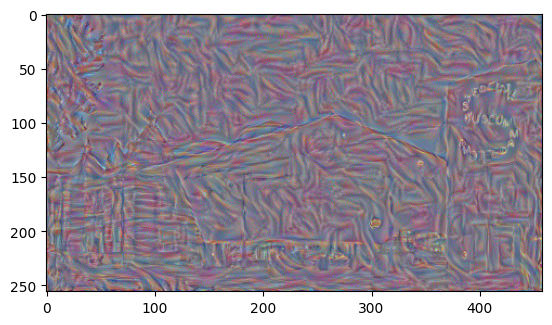

Epoch [200/1500], Content Loss: 2.4, Style Loss: 0.0, Total Loss: 3.8


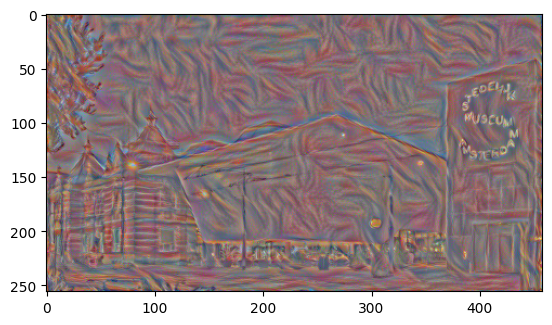

Epoch [300/1500], Content Loss: 2.0, Style Loss: 0.0, Total Loss: 2.8


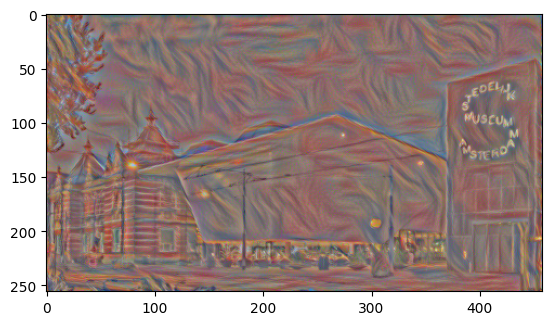

Epoch [400/1500], Content Loss: 1.7, Style Loss: 0.0, Total Loss: 2.4


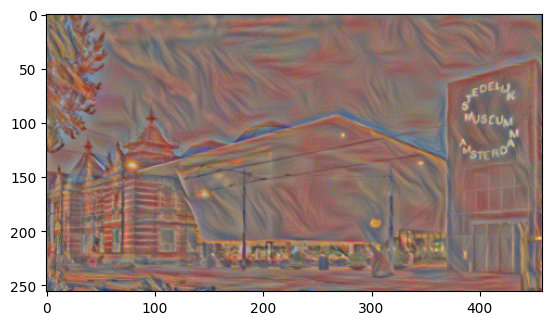

Epoch [500/1500], Content Loss: 1.6, Style Loss: 0.0, Total Loss: 2.3


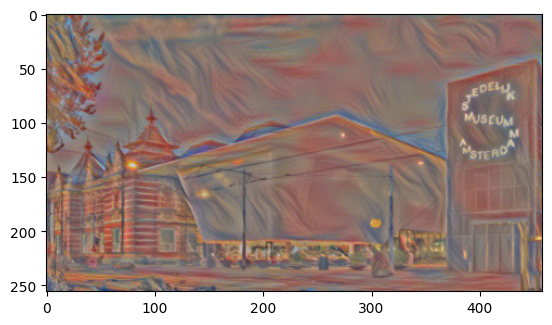

Epoch [600/1500], Content Loss: 1.5, Style Loss: 0.0, Total Loss: 2.1


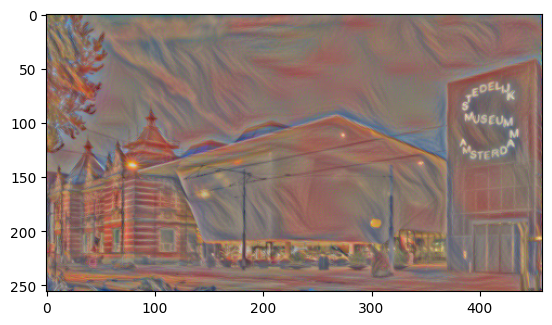

Epoch [700/1500], Content Loss: 1.5, Style Loss: 0.0, Total Loss: 2.0


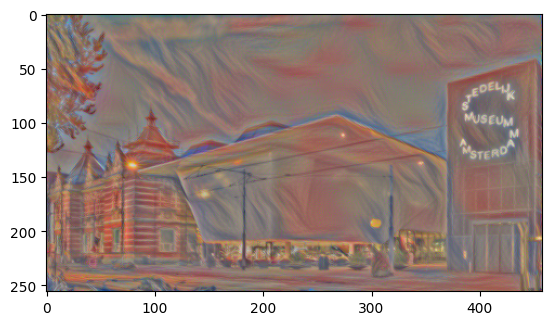

KeyboardInterrupt: 

In [72]:
# this is a scaling factor for the style loss, since the style loss can be much larger than the content loss, we need to scale it down to balance the two losses.
style_scaling = 1e6 # this can be tuned, and also depends on the transfer CNN we are using.

epochs = 1500

# the input for the RMSprop is img4target.requires_grad(). We indicate requires_grad_() to tell PyTorch that we want to compute gradients with respect
# to the target image, since we will be optimizing the target image to minimize the loss.
optimizer = torch.optim.RMSprop([img4target.requires_grad_()], lr=0.005) # the group that develop this method recommends to use RMSprop

for epoch in range(epochs):
    # extract features from the target image
    features_target = extract_features(img4target, vggnet)
    
    # compute content loss
    content_loss = 0.0
    for layer in layers4content:
        content_loss += F.mse_loss(features_target[layer], features_content[layer])
    
    # compute style loss
    style_loss = 0.0
    for i, layer in enumerate(layers4style):
        gram_target = gram_matrix(features_target[layer])
        gram_style = gram_matrix(features_style[layer])
        style_loss += weights4style[i] * F.mse_loss(gram_target, gram_style)
    
    # total loss is a weighted sum of content and style loss
    total_loss = content_loss + style_scaling * style_loss
    
    # backpropagation and optimization step
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Content Loss: {content_loss.item():.1f}, Style Loss: {style_loss.item() * style_scaling:.1f}, Total Loss: {total_loss.item():.1f}')

        # check how it looks after every 100 epochs
        final_img = img4target.squeeze().cpu().permute(1, 2, 0).detach().numpy()
        final_img = (final_img - np.min(final_img)) / (np.max(final_img) - np.min(final_img))
        plt.imshow(final_img)
        plt.show()